In [228]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import arch
import scipy.stats as stats

In [229]:
n_clip = 5000

In [230]:
data = pd.read_csv("GDAXI.csv").iloc[::-1].reset_index(drop=True)
data.head()

,Date,Open,High,Low,Close
0,01/03/00,6961.72,6750.76,6750.76,6750.76
1,01/04/00,6747.24,6586.95,6586.95,6586.95
2,01/05/00,6585.85,6502.07,6502.07,6502.07
3,01/06/00,6501.45,6474.92,6474.92,6474.92
4,01/07/00,6489.94,6780.96,6780.96,6780.96


In [231]:
X = np.log(data[" Close"]).diff().dropna()
L_train,L_test = -100*X[:n_clip],-100*X[n_clip:]

In [232]:
mu_train,mu_test = np.mean(L_train),np.mean(L_test)
sigma_train,sigma_test = np.std(L_train,ddof=1),np.std(L_test,ddof=1)


var975_cv = mu_train+sigma_train*stats.norm.ppf(0.975)
ES975_cv = mu_train+sigma_train*stats.norm.pdf(stats.norm.ppf(0.975))/(1-0.975)
print(mu_train,mu_test)
print(sigma_train,sigma_test)

-0.011947940551650335 -0.03395549493608863
1.4623310851376046 1.873846386462925


In [233]:
var975_h = np.quantile(L_train,0.975)
ES975_h = np.mean(L_train[L_train>var975_h])

In [234]:
print(var975_cv,ES975_cv)
print(var975_h,ES975_h)

2.85416831979143 3.406693753405964
3.1120007799860363 4.344422540358796


In [235]:
n_train,n_test = len(L_train),len(L_test)
c_cv_test,c_cv_train = len(L_test[L_test>var975_cv])/n_test, len(L_train[L_train>var975_cv])/n_train
c_h_test,c_h_train = len(L_test[L_test>var975_h])/n_test, len(L_train[L_train>var975_h])/n_train


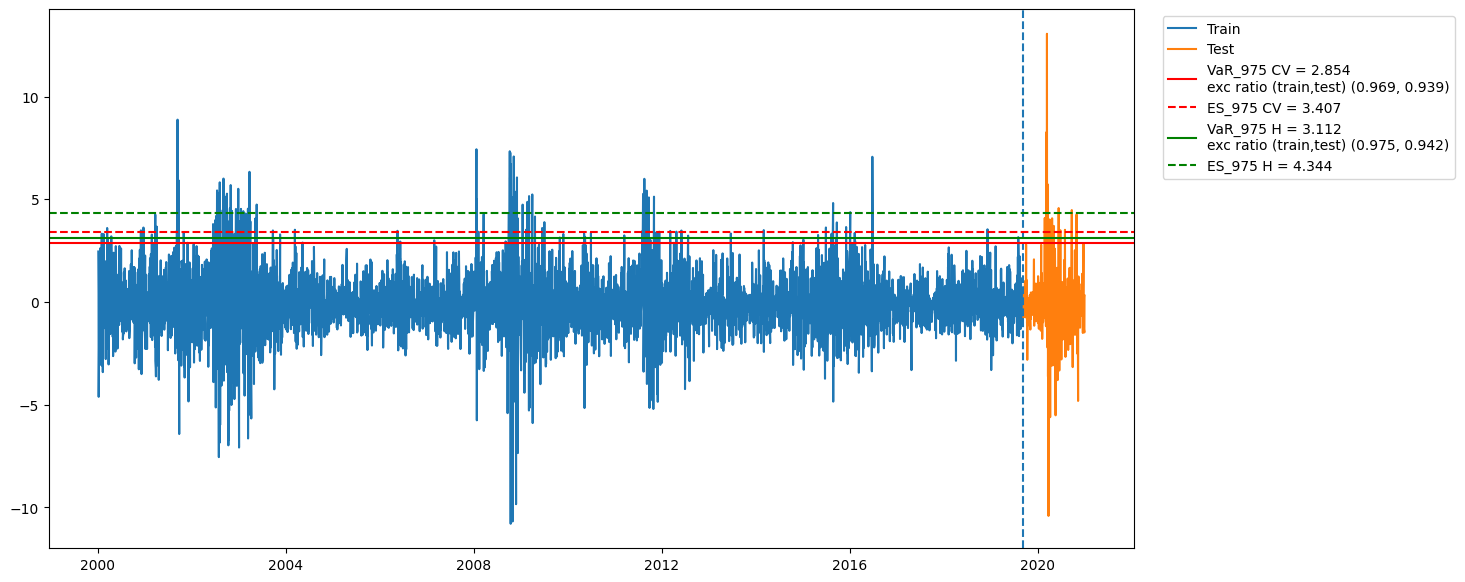

In [236]:
dates = pd.to_datetime(data["Date"], format="%m/%d/%y")
plt.figure(figsize=(14,7))
plt.plot(dates[1:n_clip+1],L_train,label="Train")
plt.plot(dates[n_clip+1:],L_test,label="Test")
plt.axvline(dates[n_clip+1],linestyle="--")
plt.axhline(var975_cv,color="red",label=f"VaR_975 CV = {round(var975_cv,3)} \nexc ratio (train,test) {round(1-c_cv_train,3),round(1-c_cv_test,3)}")
plt.axhline(ES975_cv,color="red",linestyle="--",label=f"ES_975 CV = {round(ES975_cv,3)}")
plt.axhline(var975_h,color="green",label=f"VaR_975 H = {round(var975_h,3)} \nexc ratio (train,test) {round(1-c_h_train,3),round(1-c_h_test,3)}")
plt.axhline(ES975_h,color="green",linestyle="--",label=f"ES_975 H = {round(ES975_h,3)}")

plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.show()

In [237]:
model = arch.arch_model(L_train,vol="GARCH",p=1,q=1)
res = model.fit(disp="off")

print(f"alpha0 = {round(res.params['omega'],3)}")
print(f"alpha1 = {round(res.params['alpha[1]'],3)}")
print(f"beta1 = {round(res.params['beta[1]'],3)}")
alpha0=res.params['omega'];alpha1 = res.params['alpha[1]']; beta1=res.params['beta[1]']


alpha0 = 0.023
alpha1 = 0.089
beta1 = 0.899


In [238]:
np.random.seed(6)
N = len(L_train)+len(L_test)
Ld =np.concatenate((L_train,L_test))
V = np.zeros(shape=(N))
V[0] = alpha0/(1-(alpha1+beta1))
for t in range(0,N-1):
    V[t+1] = alpha0+alpha1*Ld[t]**2+beta1*V[t]

-0.01183495867898723 1.0016629640725438


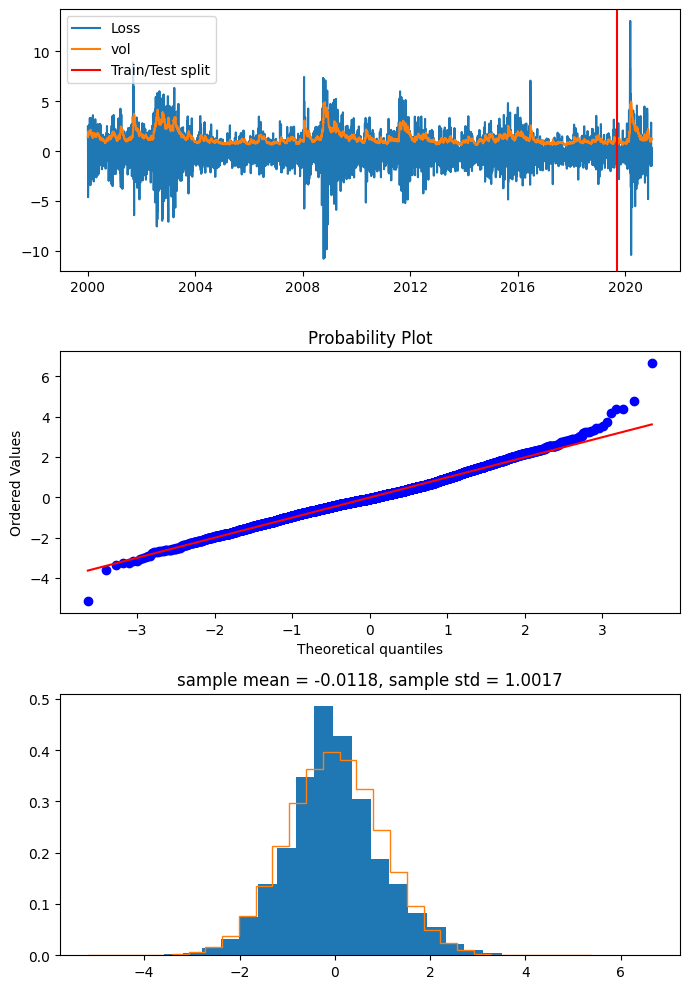

In [239]:

Z = (Ld/np.sqrt(V))[:n_clip]
mu_Z = np.mean(Z)
sigma_Z = np.std(Z,ddof=1)
print(mu_Z,sigma_Z)

plt.figure(figsize=(7,10))
plt.subplot(3,1,1)
plt.plot(dates[1:],Ld,label="Loss")
plt.plot(dates[1:],np.sqrt(V),label="vol")
plt.axvline(dates[n_clip+1],color="red",label="Train/Test split")
plt.legend()

plt.subplot(3,1,2)
stats.probplot(Z,plot=plt)
plt.subplot(3,1,3)
plt.hist(Z,bins=30,density=True)
plt.hist(np.random.normal(mu_Z,sigma_Z,1000*n_train),bins=30,density=True,histtype="step")
plt.title(f"sample mean = {round(mu_Z,4)}, sample std = {round(sigma_Z,4)}")
plt.tight_layout()
plt.show()

In [240]:
Z_var975_cv = mu_Z+sigma_Z*stats.norm.ppf(0.975)
Z_ES975_cv = mu_Z+sigma_Z*stats.norm.pdf(stats.norm.ppf(0.975))/(1-0.975)

Z_var975_h = np.quantile(Z,0.975)
Z_ES975_h = np.mean(Z[Z>Z_var975_h])

print(Z_var975_cv,Z_var975_h)
print(Z_ES975_cv,Z_ES975_h)

Lt_var975_cv = np.sqrt(V)*Z_var975_cv
Lt_var975_h = np.sqrt(V)*Z_var975_h
Lt_ES975_cv = np.sqrt(V)*Z_ES975_cv
Lt_ES975_h = np.sqrt(V)*Z_ES975_h

1.9513883755508368 2.1230287814407727
2.3298555155745495 2.6015961354996278


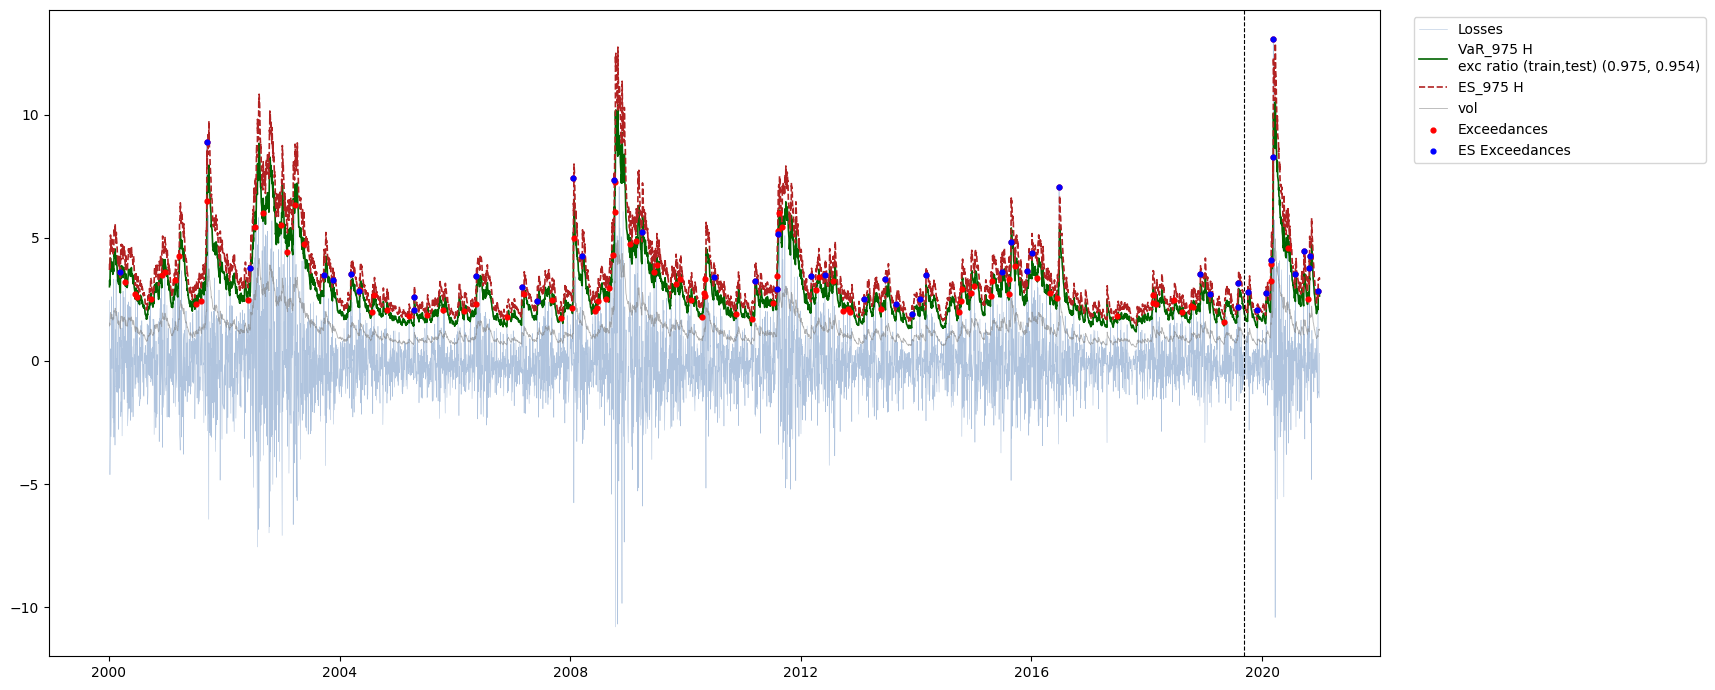

In [241]:
n = len(Ld)
d = dates[-n:]
exc = Ld > Lt_var975_h
c_tr, c_te = np.mean(exc[:n_clip]), np.mean(exc[n_clip:])

plt.figure(figsize=(14,7))
plt.plot(d, Ld, lw=0.4, color="lightsteelblue", label="Losses")
plt.plot(d, Lt_var975_h, color="darkgreen", lw=1.2,
         label=f"VaR_975 H\nexc ratio (train,test) {round(1-c_tr,3), round(1-c_te,3)}")
plt.plot(d, Lt_ES975_h, color="firebrick", ls="--", lw=1.2, label="ES_975 H")
plt.plot(d, np.sqrt(V), color="gray", lw=0.6, alpha=0.6, label="vol")
plt.scatter(d[exc], Ld[exc], color="red", s=12, zorder=5, label="Exceedances")
plt.axvline(d.iloc[n_clip], color="black", ls="--", lw=0.8)
exc_es = Ld > Lt_ES975_h
plt.scatter(d[exc_es], Ld[exc_es], color="blue", s=12, zorder=6, label="ES Exceedances")
plt.tight_layout()
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.show()

In [242]:
print(Lt_var975_cv.shape)
print(Lt_var975_h.shape)
print(Ld.shape)

(5329,)
(5329,)
(5329,)


In [243]:
X = Lt_var975_h[n_clip+1:]
X_ = var975_h*np.ones_like(X)

Y = Ld[n_clip+1:]



In [244]:
def S(X,Y,alpha):
    return (1*(Y<X)-alpha)*(X-Y)

In [245]:
A = S(X,Y,0.975)
B = S(X_,Y,0.975)
T = np.mean(A-B)

d =  A-B

print(np.mean(A))
print(np.mean(B))
T_n = np.mean(d)
print(f"T:{T_n}")
DM = np.sqrt(len(d)) * T_n / np.std(d, ddof=1)
p_value = stats.norm.sf((DM))
print(f"p:{p_value}")

0.15550426692707214
0.17518138497939242
T:-0.01967711805232024
p:0.8776128871642059


In [246]:
DM = np.sqrt(len(d)) * np.mean(d) / np.std(d, ddof=1)
p_value = stats.norm.sf(DM)
print(p_value)

0.8776128871642059


In [247]:
import numpy as np
import pandas as pd

alpha = 0.975

def var_es_metrics(VaR, ES, Y, alpha=0.975):
    VaR = np.asarray(VaR)
    ES = np.asarray(ES)
    Y = np.asarray(Y)

    exceed_var = Y >= VaR
    exceed_es = Y >= ES

    var_excess = Y[exceed_var] - VaR[exceed_var]
    es_excess = Y[exceed_es] - ES[exceed_es]

    realized_tail = Y[exceed_var]
    forecast_tail_es = ES[exceed_var]

    return {
        "mean_VaR": np.mean(VaR),
        "mean_ES": np.mean(ES),

        "hit_rate": np.mean(Y < VaR),
        "VaR_exceedance_count": np.sum(exceed_var),
        "VaR_exceedance_rate": np.mean(exceed_var),
        "expected_exceedance_rate": 1 - alpha,
        "VaR_exceedance_ratio": np.mean(exceed_var) / (1 - alpha),

        "mean_above_VaR": np.mean(var_excess) if var_excess.size else 0.0,
        "max_above_VaR": np.max(var_excess) if var_excess.size else 0.0,

        "realized_tail_mean": (
            np.mean(realized_tail) if realized_tail.size else np.nan
        ),
        "forecast_ES_on_breach_days": (
            np.mean(forecast_tail_es) if forecast_tail_es.size else np.nan
        ),
        "ES_calibration_gap": (
            np.mean(realized_tail - forecast_tail_es)
            if realized_tail.size else np.nan
        ),

        "ES_exceedance_count": np.sum(exceed_es),
        "ES_exceedance_rate": np.mean(exceed_es),
        "mean_above_ES": np.mean(es_excess) if es_excess.size else 0.0,
        "max_above_ES": np.max(es_excess) if es_excess.size else 0.0,
    }


sl = slice(n_clip + 1, n_clip + 250)

X = Lt_var975_h[sl]
X_ = var975_h * np.ones_like(X)

eX = Lt_ES975_h[sl]
eX_ = ES975_h * np.ones_like(eX)

Y = Ld[sl]

results = pd.DataFrame({
    "Dynamic": var_es_metrics(X, eX, Y, alpha),
    "Static": var_es_metrics(X_, eX_, Y, alpha),
})

print(results)

                              Dynamic     Static
mean_VaR                     3.498659   3.112001
mean_ES                      4.287317   4.344423
hit_rate                     0.959839   0.935743
VaR_exceedance_count        10.000000  16.000000
VaR_exceedance_rate          0.040161   0.064257
expected_exceedance_rate     0.025000   0.025000
VaR_exceedance_ratio         1.606426   2.570281
mean_above_VaR               1.766863   1.781719
max_above_VaR                7.051572   9.942860
realized_tail_mean           4.833159   4.893720
forecast_ES_on_breach_days   3.757492   4.344423
ES_calibration_gap           1.075667   0.549297
ES_exceedance_count          7.000000   5.000000
ES_exceedance_rate           0.028112   0.020080
mean_above_ES                1.817606   3.071495
max_above_ES                 5.698327   8.710438


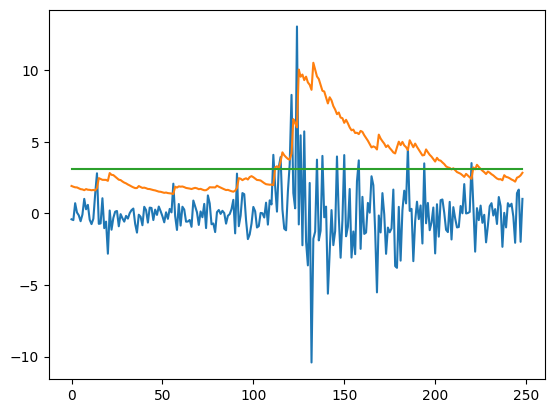

In [248]:
plt.plot(Y)
plt.plot(X)
plt.plot(X_)
plt.show()
